------------
cluster= 0
amplitude= 1.8389506557354818 idx= (np.int64(3), np.int64(6), np.int64(153), np.int64(141))
selected elements: 62630
------------
cluster= 1
amplitude= 0.78625134606968 idx= (np.int64(14), np.int64(9), np.int64(90), np.int64(77))
selected elements: 654292
------------
cluster= 2
amplitude= 0.7742814375734681 idx= (np.int64(13), np.int64(10), np.int64(90), np.int64(77))
selected elements: 67399


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 14.25it/s]


cluster 0: amp=1.839, peak|rec|=2.162
cluster 1: amp=0.786, peak|rec|=2.249


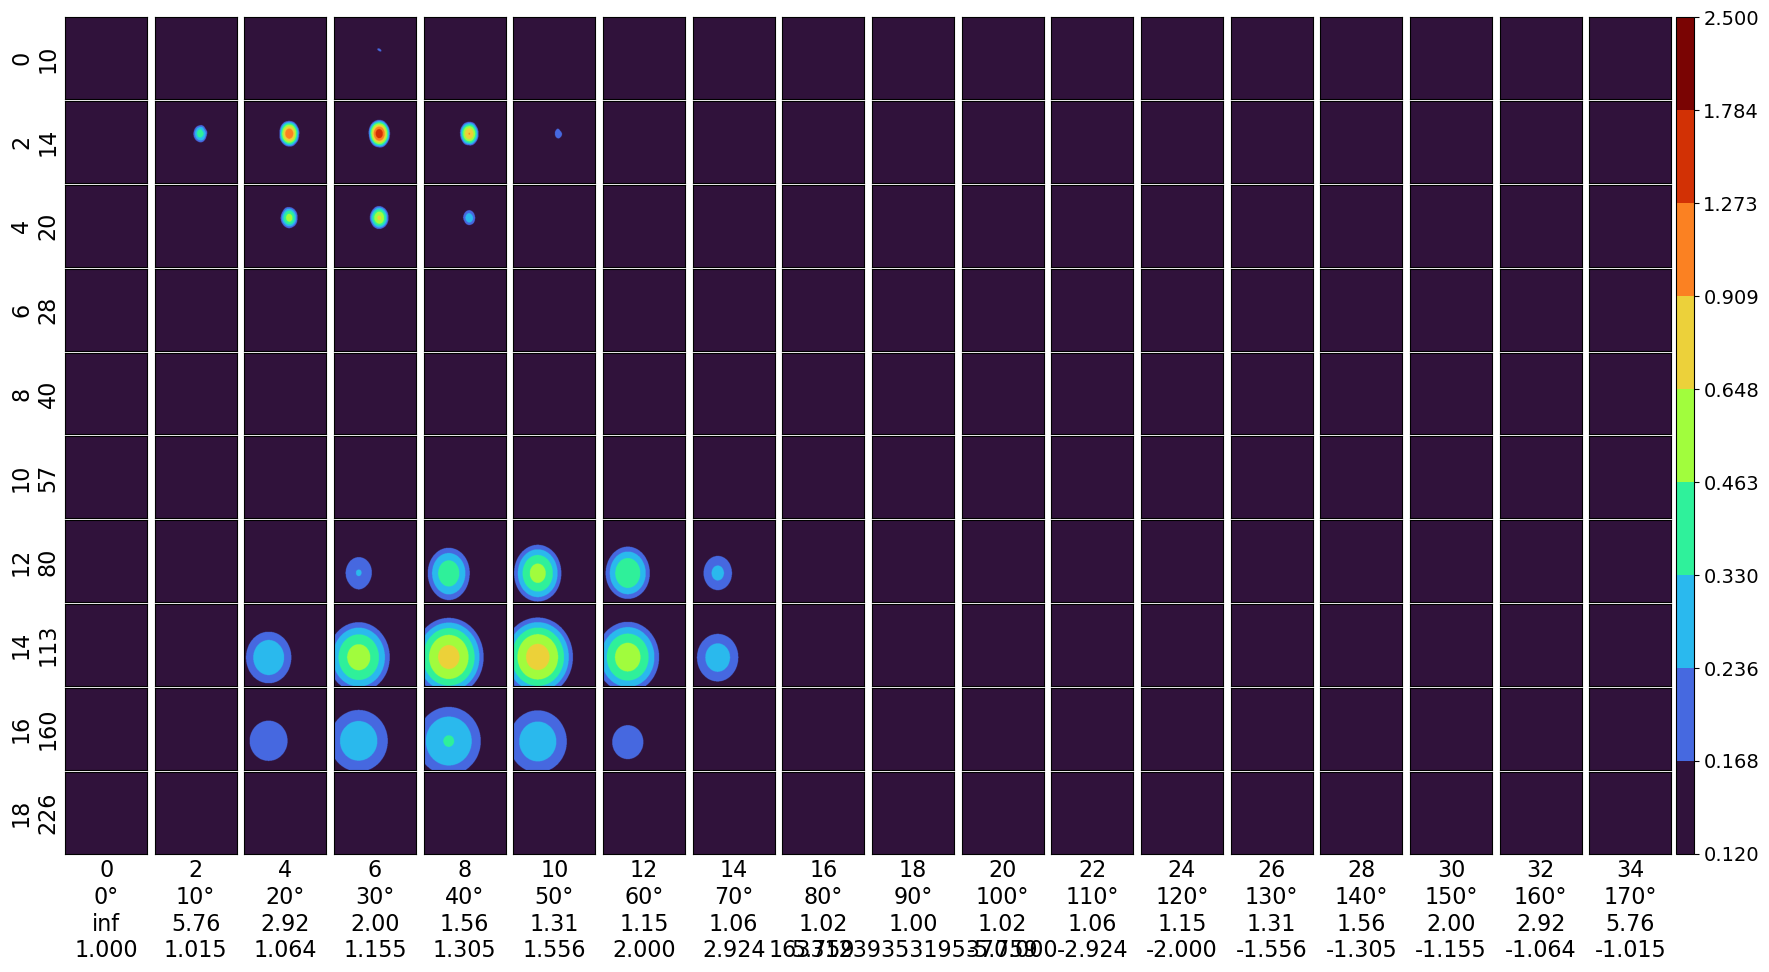

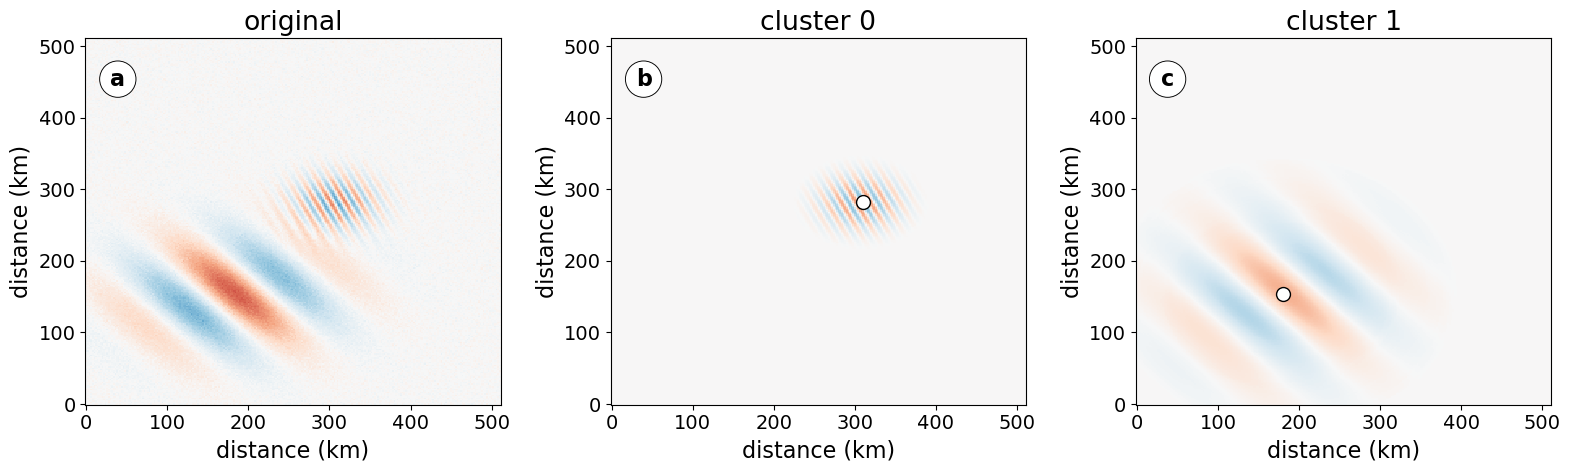

In [20]:
# example_decompose2d_synthetic_packets_only.py
# Synthetic 2D field with a couple of Gaussian wave packets (NO Kelvin wake),
# then run juwavelet 2D CWT and plot: original + 2 reconstructed clusters.

from __future__ import annotations
import math
import string
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Sequence, Tuple

# Inline plotting if you're in Jupyter
try:
    get_ipython  # type: ignore[name-defined]
    %matplotlib inline
except Exception:
    pass

from juwavelet import transform, utils

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})

# --------------------------
# Wave packets
# --------------------------
@dataclass
class WavePacket:
    """2D plane-wave packet with Gaussian envelope.
       A * exp(-((x-x0)^2/(2*sx^2) + (y-y0)^2/(2*sy^2))) * cos(kx*x + ky*y + phi)
       Provide (kx, ky) or (k, theta) in radians.
    """
    amplitude: float = 1.0
    kx: float | None = None
    ky: float | None = None
    k: float | None = None
    theta: float | None = None
    x0: float = 0.0
    y0: float = 0.0
    sx: float = 10.0
    sy: float = 10.0
    phi: float = 0.0

    def k_components(self) -> Tuple[float, float]:
        if self.kx is not None and self.ky is not None:
            return self.kx, self.ky
        if self.k is None or self.theta is None:
            raise ValueError("Provide either (kx, ky) or (k, theta) for WavePacket.")
        return self.k * math.cos(self.theta), self.k * math.sin(self.theta)

# --------------------------
# Grid + helpers
# --------------------------
def make_grid(nx: int, ny: int, dx: float, dy: float) -> Tuple[np.ndarray, np.ndarray]:
    x = np.arange(nx, dtype=float) * dx
    y = np.arange(ny, dtype=float) * dy
    X, Y = np.meshgrid(x, y)  # shapes (ny, nx)
    return X, Y

def packet_field(xs: np.ndarray, ys: np.ndarray, pkt: WavePacket) -> np.ndarray:
    kx, ky = pkt.k_components()
    gauss = np.exp(
        -(
            ((xs - pkt.x0) ** 2) / (2 * pkt.sx ** 2)
            + ((ys - pkt.y0) ** 2) / (2 * pkt.sy ** 2)
        )
    )
    phase = kx * xs + ky * ys + pkt.phi
    return pkt.amplitude * gauss * np.cos(phase)

# --------------------------
# Synthetic field (packets only)
# --------------------------
def generate_synthetic_field(
    nx: int = 256,
    ny: int = 256,
    dx: float = 2.0,
    dy: float = 2.0,
    packets: Sequence[WavePacket] | None = None,
    noise_sigma: float = 0.10,
    seed: int | None = 0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns xs, ys, total_field with shapes (ny, nx).
    """
    rng = np.random.default_rng(seed) if seed is not None else np.random.default_rng()
    xs, ys = make_grid(nx, ny, dx, dy)
    Lx = nx * dx
    Ly = ny * dy

    if packets is None:
        packets = [
            WavePacket(
                amplitude=3.0,
                k=2 * math.pi / 120.0,
                theta=math.radians(45),
                x0=0.35 * Lx,
                y0=0.30 * Ly,
                sx=86,
                sy=56,
                phi=0.0,
            ),
            WavePacket(
                amplitude=2.5,
                k=2 * math.pi / 16.0,
                theta=math.radians(28),
                x0=0.60 * Lx,
                y0=0.55 * Ly,
                sx=38,
                sy=28,
                phi=0.6,
            ),
        ]

    field = np.zeros_like(xs)
    for pkt in packets:
        field += packet_field(xs, ys, pkt)

    if noise_sigma > 0:
        field = field + rng.normal(0.0, noise_sigma, size=field.shape)

    return xs, ys, field

# --------------------------
# Pipeline
# --------------------------
def run_pipeline():
    # Build synthetic field (NO Kelvin wake)
    xs2d, ys2d, wave = generate_synthetic_field(
        nx=256, ny=256, dx=2.0, dy=2.0, seed=0
    )

    x1d = xs2d[0, :].copy()
    y1d = ys2d[:, 0].copy()
    x1d -= x1d[0]
    dx = np.diff(x1d).mean()
    dy = np.diff(y1d).mean()

    # juwavelet expects (nx, ny), so transpose
    wave_xy = wave.T

    cwt = transform.decompose2d(
        wave_xy, dx=dx, dy=dy, s0=10, dj=0.25, js=20, jt=36, aspect=1
    )

    # Identify clusters (waves)
    amps, idxs, iwave = utils.identify_cluster2d(cwt, min_amp=.5, thr=0.25)

    decomposition = cwt["decomposition"]
    orig_decomp = decomposition.copy()

    # Overview CWT plot (optional but nice)
    cmap = matplotlib.cm.turbo
    norm = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.12), np.log(2.5), 10)), cmap.N
    )
    fig1, _ = utils.plot_decomposition2d(cwt, redux_s=2, redux_t=2, cmap=cmap, norm=norm)

    # Choose two clusters to plot (strongest two by amps, if available)
    if isinstance(amps, np.ndarray) and amps.size >= 2:
        pick = np.argsort(amps)[::-1][:2].tolist()
    else:
        pick = [0, 1]

    # Plot: original + 2 reconstructed clusters
    fig2, axs = plt.subplots(1, 3, figsize=(16, 5))
    opts = {"cmap": "RdBu_r", "vmin": -5, "vmax": 5, "rasterized": True}

    axs[0].set_title("original")
    axs[0].pcolormesh(x1d, y1d, wave, shading="auto", **opts)

    for j, cl in enumerate(pick, start=1):
        decomposition[:] = orig_decomp
        decomposition[iwave != cl] = 0
        rec = transform.reconstruct2d(cwt)  # (nx, ny)

        axs[j].set_title(f"cluster {cl}")
        axs[j].pcolormesh(x1d, y1d, rec.T, shading="auto", **opts)

        # mark the cluster's peak location (in the reconstructed map)
        A = np.abs(rec.T)  # (ny, nx) in plotting orientation
        iy, ix = np.unravel_index(np.argmax(A), A.shape)
        axs[j].plot(x1d[ix], y1d[iy], "o", color="w", mec="k", ms=10)

        # print a tiny summary
        try:
            print(f"cluster {cl}: amp={amps[cl]:.3f}, peak|rec|={A[iy, ix]:.3f}")
        except Exception:
            print(f"cluster {cl}: peak|rec|={A[iy, ix]:.3f}")

    for ax in axs:
        ax.set_xlabel("distance (km)")
        ax.set_ylabel("distance (km)")

    # letter tags
    letterbox = {"boxstyle": "circle", "lw": 0.67, "facecolor": "white", "edgecolor": "black"}
    for ax, letter in zip(axs, string.ascii_lowercase):
        ax.text(0.06, 0.92, letter, transform=ax.transAxes,
                bbox=letterbox, va="top", ha="left", weight="bold")

    fig2.tight_layout()
    plt.show(fig1)
    plt.show(fig2)

# --------------------------
# Run
# --------------------------
run_pipeline()


------------
cluster= 0
amplitude= 1.8389506557354818 idx= (np.int64(3), np.int64(6), np.int64(153), np.int64(141))
selected elements: 62630
------------
cluster= 1
amplitude= 0.78625134606968 idx= (np.int64(14), np.int64(9), np.int64(90), np.int64(77))
selected elements: 654292
------------
cluster= 2
amplitude= 0.7742814375734681 idx= (np.int64(13), np.int64(10), np.int64(90), np.int64(77))
selected elements: 67399


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 28.04it/s]


cluster 0: amp=1.839, λ=16.82 km, θ=30.00 deg, ref_phase(phi0)=-0.571 rad
cluster 1: amp=0.786, λ=113.14 km, θ=45.00 deg, ref_phase(phi0)=0.506 rad


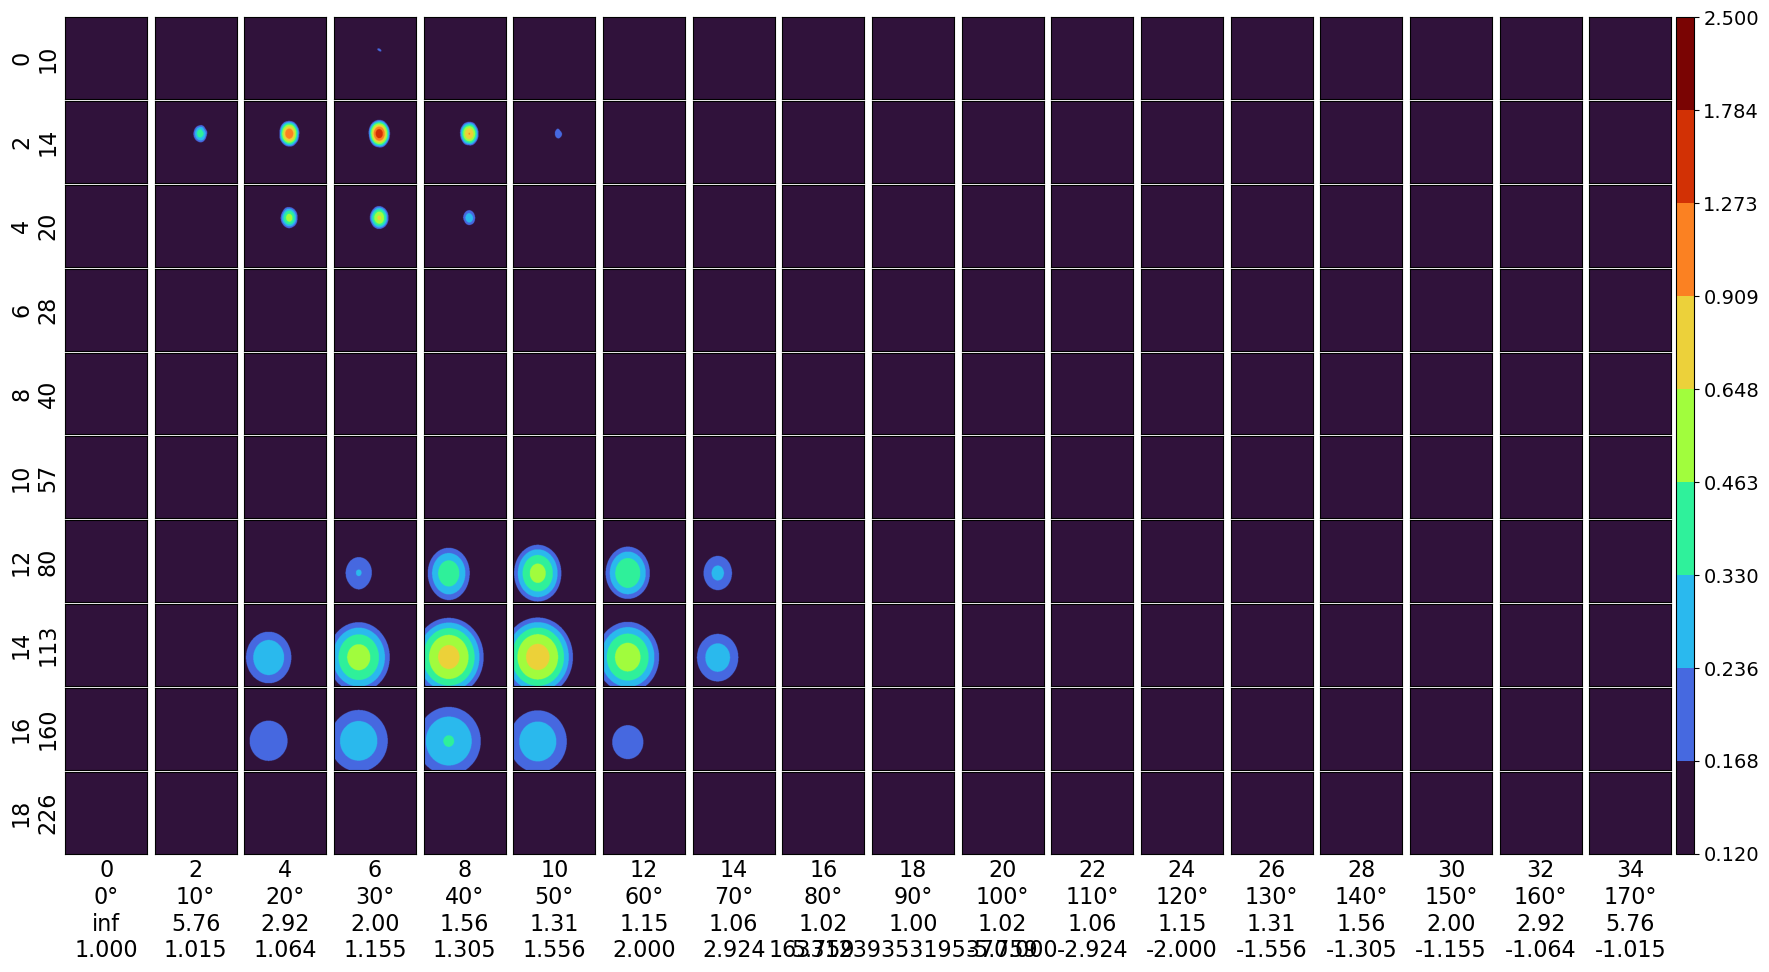

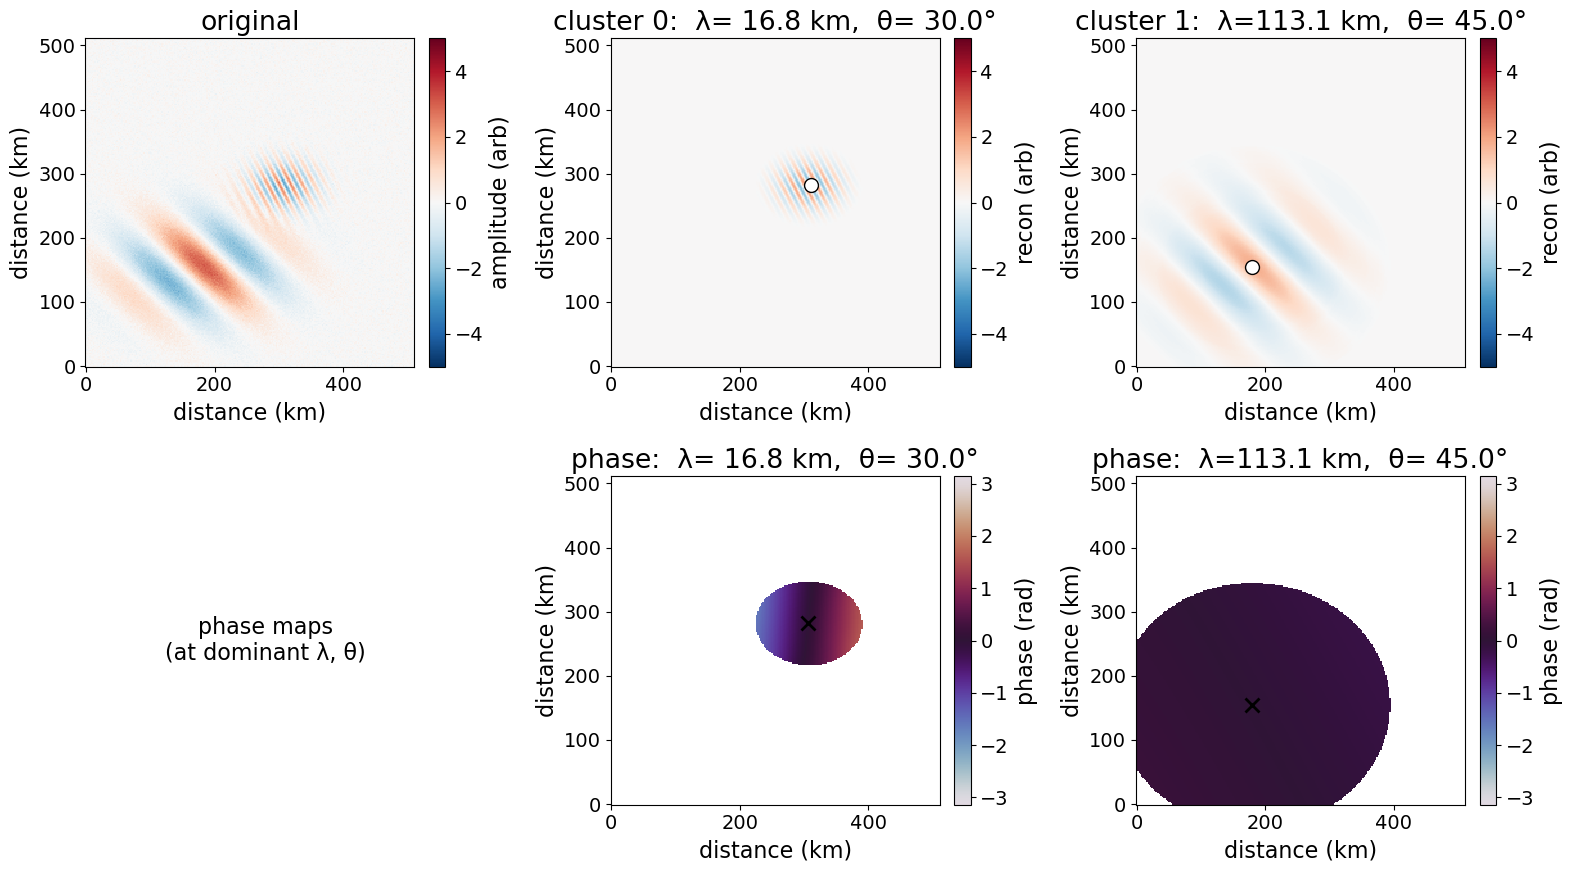

In [40]:
# example_decompose2d_synthetic_packets_only.py
# Synthetic 2D field with a couple of Gaussian wave packets (NO Kelvin wake),
# then run juwavelet 2D CWT and plot:
#   original + 2 reconstructed clusters + phase maps (dominant scale, theta) for each cluster

from __future__ import annotations
import math
import string
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Sequence, Tuple

# Inline plotting if you're in Jupyter
try:
    get_ipython  # type: ignore[name-defined]
    %matplotlib inline
except Exception:
    pass

from juwavelet import transform, utils

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})

# --------------------------
# Wave packets
# --------------------------
@dataclass
class WavePacket:
    """2D plane-wave packet with Gaussian envelope.
       A * exp(-((x-x0)^2/(2*sx^2) + (y-y0)^2/(2*sy^2))) * cos(kx*x + ky*y + phi)
       Provide (kx, ky) or (k, theta) in radians.
    """
    amplitude: float = 1.0
    kx: float | None = None
    ky: float | None = None
    k: float | None = None
    theta: float | None = None
    x0: float = 0.0
    y0: float = 0.0
    sx: float = 10.0
    sy: float = 10.0
    phi: float = 0.0

    def k_components(self) -> Tuple[float, float]:
        if self.kx is not None and self.ky is not None:
            return self.kx, self.ky
        if self.k is None or self.theta is None:
            raise ValueError("Provide either (kx, ky) or (k, theta) for WavePacket.")
        return self.k * math.cos(self.theta), self.k * math.sin(self.theta)

# --------------------------
# Grid + helpers
# --------------------------
def make_grid(nx: int, ny: int, dx: float, dy: float) -> Tuple[np.ndarray, np.ndarray]:
    x = np.arange(nx, dtype=float) * dx
    y = np.arange(ny, dtype=float) * dy
    X, Y = np.meshgrid(x, y)  # shapes (ny, nx)
    return X, Y

def packet_field(xs: np.ndarray, ys: np.ndarray, pkt: WavePacket) -> np.ndarray:
    kx, ky = pkt.k_components()
    gauss = np.exp(
        -(
            ((xs - pkt.x0) ** 2) / (2 * pkt.sx ** 2)
            + ((ys - pkt.y0) ** 2) / (2 * pkt.sy ** 2)
        )
    )
    phase = kx * xs + ky * ys + pkt.phi
    return pkt.amplitude * gauss * np.cos(phase)

# --------------------------
# Synthetic field (packets only)
# --------------------------
def generate_synthetic_field(
    nx: int = 256,
    ny: int = 256,
    dx: float = 2.0,
    dy: float = 2.0,
    packets: Sequence[WavePacket] | None = None,
    noise_sigma: float = 0.10,
    seed: int | None = 0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns xs, ys, total_field with shapes (ny, nx).
    """
    rng = np.random.default_rng(seed) if seed is not None else np.random.default_rng()
    xs, ys = make_grid(nx, ny, dx, dy)
    Lx = nx * dx
    Ly = ny * dy

    if packets is None:
        packets = [
            WavePacket(
                amplitude=3.0,
                k=2 * math.pi / 120.0,
                theta=math.radians(45),
                x0=0.35 * Lx,
                y0=0.30 * Ly,
                sx=86,
                sy=56,
                phi=0.0,
            ),
            WavePacket(
                amplitude=2.5,
                k=2 * math.pi / 16,
                theta=math.radians(28),
                x0=0.60 * Lx,
                y0=0.55 * Ly,
                sx=38,
                sy=28,
                phi=0.6,
            ),
        ]

    field = np.zeros_like(xs)
    for pkt in packets:
        field += packet_field(xs, ys, pkt)

    if noise_sigma > 0:
        field = field + rng.normal(0.0, noise_sigma, size=field.shape)

    return xs, ys, field

# --------------------------
# Helpers for phase plotting
# --------------------------
def phase_map_for_cluster(cwt: dict, iwave: np.ndarray, idxs, cluster_id: int) -> tuple[np.ndarray, float, float]:
    """
    Returns:
      phase_plot (ny, nx) with NaN outside the cluster mask at dominant (scale, theta),
      wavelength_x_dom, wavelength_y_dom
    """
    # dominant indices for this cluster
    udx = idxs[cluster_id]  # typically (a_scale, a_theta, ix, iy)
    a1 = int(udx[0])
    a2 = int(udx[1])

    coeff = cwt["decomposition"][a1, a2, :, :]  # (nx, ny), complex
    ph = np.angle(coeff)                        # (nx, ny) in wave_xy orientation

    # keep only coefficients that belong to this cluster at the dominant (a1,a2)
    mask = (iwave[a1, a2, :, :] == cluster_id)  # (nx, ny)
    ph_masked = np.full_like(ph, np.nan, dtype=float)
    ph_masked[mask] = ph[mask]

    # return in plotting orientation (ny, nx)
    ph_plot = ph_masked.T

    wx = float(cwt["wavelength_x"][a1, a2])
    wy = float(cwt["wavelength_y"][a1, a2])
    return ph_plot, wx, wy

# --------------------------
# Pipeline
# --------------------------
def run_pipeline():
    # Build synthetic field (NO Kelvin wake)
    xs2d, ys2d, wave = generate_synthetic_field(
        nx=256, ny=256, dx=2.0, dy=2.0, seed=0
    )

    x1d = xs2d[0, :].copy()
    y1d = ys2d[:, 0].copy()
    x1d -= x1d[0]
    dx = np.diff(x1d).mean()
    dy = np.diff(y1d).mean()

    # juwavelet expects (nx, ny), so transpose
    wave_xy = wave.T

    cwt = transform.decompose2d(
        wave_xy, dx=dx, dy=dy, s0=10, dj=0.25, js=20, jt=36, aspect=1
    )

    # Identify clusters (waves)
    amps, idxs, iwave = utils.identify_cluster2d(cwt, min_amp=0.5, thr=0.25)

    decomposition = cwt["decomposition"]          # (js, jt, nx, ny), complex
    orig_decomp = decomposition.copy()
    thetas = cwt["theta"]                         # (jt,)
    periods = cwt["period"]                       # (js,) overall wavelength/scale

    # Overview CWT plot (optional)
    cmap = matplotlib.cm.turbo
    norm = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.12), np.log(2.5), 10)), cmap.N
    )
    fig1, _ = utils.plot_decomposition2d(cwt, redux_s=2, redux_t=2, cmap=cmap, norm=norm)

    # Pick two strongest clusters
    if isinstance(amps, np.ndarray) and amps.size >= 2:
        pick = np.argsort(amps)[::-1][:2].tolist()
    else:
        pick = [0, 1]

    # --- Main figure: top row amplitude, bottom row phase
    fig2, axs = plt.subplots(2, 3, figsize=(16, 9))
    cmap_amp = "RdBu_r"
    cmap_ph = "twilight"  # cyclic, good for phase
    opts_amp = {"cmap": cmap_amp, "vmin": -5, "vmax": 5, "rasterized": True}
    opts_ph = {"cmap": cmap_ph, "vmin": -np.pi, "vmax": np.pi, "rasterized": True}

    # original (top-left)
    axs[0, 0].set_title("original")
    im0 = axs[0, 0].pcolormesh(x1d, y1d, wave, shading="auto", **opts_amp)
    cb0 = fig2.colorbar(im0, ax=axs[0, 0], fraction=0.046, pad=0.04)
    cb0.set_label("amplitude (arb)")

    # bottom-left: just a label panel
    axs[1, 0].axis("off")
    axs[1, 0].text(
        0.5, 0.5, "phase maps\n(at dominant λ, θ)",
        ha="center", va="center", transform=axs[1, 0].transAxes
    )

    for col, cl in enumerate(pick, start=1):
        if not (isinstance(idxs, (list, tuple)) and cl < len(idxs)):
            axs[0, col].set_title(f"cluster {cl} not found")
            axs[0, col].axis("off")
            axs[1, col].axis("off")
            continue

        # Dominant index for this cluster: (iscale, itheta, ix_peak, iy_peak) in (nx, ny) indexing
        udx = idxs[cl]
        iscale, itheta = int(udx[0]), int(udx[1])

        lam = float(periods[iscale])                      # km
        theta_deg = float(np.degrees(thetas[itheta]))     # degrees

        # --- Reconstruct this cluster (amplitude plot)
        decomposition[:] = orig_decomp
        decomposition[iwave != cl] = 0
        rec = transform.reconstruct2d(cwt)  # (nx, ny), real

        axs[0, col].set_title(rf"cluster {cl}:  λ={lam:5.1f} km,  θ={theta_deg:5.1f}°")
        imA = axs[0, col].pcolormesh(x1d, y1d, rec.T, shading="auto", **opts_amp)
        cbA = fig2.colorbar(imA, ax=axs[0, col], fraction=0.046, pad=0.04)
        cbA.set_label("recon (arb)")

        # mark peak location in the reconstruction
        Aabs = np.abs(rec.T)  # (ny, nx)
        iy_max, ix_max = np.unravel_index(np.argmax(Aabs), Aabs.shape)
        axs[0, col].plot(x1d[ix_max], y1d[iy_max], "o", color="w", mec="k", ms=10)

        # --- Phase at dominant (iscale, itheta)
        coeff_dom = orig_decomp[iscale, itheta, :, :]          # (nx, ny), complex
        coeff_dom_plot = coeff_dom.T                           # (ny, nx) for plotting
        phase_dom = np.angle(coeff_dom_plot)                   # wrapped [-pi, pi]

        # mask: only keep pixels belonging to this cluster at (iscale, itheta)
        mask = (iwave[iscale, itheta, :, :].T == cl)           # (ny, nx)

        # Choose a reference phase from the strongest coefficient INSIDE the mask
        # (this makes the phase map visually consistent: peak -> phase 0)
        coeff_in = np.where(mask, coeff_dom_plot, np.nan + 1j*np.nan)
        # amplitude of coeffs, ignoring nans
        amp_in = np.abs(coeff_in)
        if np.all(~np.isfinite(amp_in)):
            # nothing to show
            axs[1, col].set_title("phase (no support)")
            axs[1, col].axis("off")
            continue

        iy_ref, ix_ref = np.unravel_index(np.nanargmax(amp_in), amp_in.shape)
        phi0 = np.angle(coeff_dom_plot[iy_ref, ix_ref])        # reference phase

        # re-reference phase: subtract phi0 (equivalently multiply by exp(-i phi0))
        phase_ref = np.angle(coeff_dom_plot * np.exp(-1j * phi0))

        # apply mask
        phase_plot = phase_ref.copy()
        phase_plot[~mask] = np.nan

        axs[1, col].set_title(rf"phase:  λ={lam:5.1f} km,  θ={theta_deg:5.1f}°")
        imP = axs[1, col].pcolormesh(x1d, y1d, phase_plot, shading="auto", **opts_ph)
        cbP = fig2.colorbar(imP, ax=axs[1, col], fraction=0.046, pad=0.04)
        cbP.set_label("phase (rad)")

        # mark reference point
        axs[1, col].plot(x1d[ix_ref], y1d[iy_ref], "x", color="k", ms=10, mew=2)

        # console summary
        print(
            f"cluster {cl}: amp={amps[cl]:.3f}, λ={lam:.2f} km, θ={theta_deg:.2f} deg, "
            f"ref_phase(phi0)={phi0:.3f} rad"
        )

    for r in range(2):
        for c in range(3):
            if axs[r, c].axison:
                axs[r, c].set_xlabel("distance (km)")
                axs[r, c].set_ylabel("distance (km)")

    fig2.tight_layout()
    plt.show(fig1)
    plt.show(fig2)

# --------------------------
# Run
# --------------------------
run_pipeline()
